# Random Sample Check — `the_cauldron_ZH_dsV32_filtered_merged.parquet`

This notebook loads the locally-built Chinese Cauldron parquet file via `load_mixed_data_v2`
and runs a series of random sample checks so you can visually inspect:

- **Image rendering** — confirm images decode correctly
- **Conversation text** — verify user / assistant turns look sensible
- **Basic statistics** — row count, turn lengths, image count distribution

The parquet file is expected to follow the Cauldron schema:
```
images  → Sequence(Image())          # list of PIL images (may be empty for text-only rows)
texts   → [{user, assistant, source}] # list of conversation turns
```

## 0. Setup

In [1]:
import os
import sys
import random
import warnings

import html as _html
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML
from collections import Counter

warnings.filterwarnings('ignore')

# ── Project root resolution ────────────────────────────────────────────────────
# The notebook lives in  <repo_root>/notebooks/  so we add the train directory
# to sys.path so that `from train import ...` works without installing the package.
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT    = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
TRAIN_DIR    = os.path.join(REPO_ROOT, 'qwen3smvl', 'train')

for _p in [REPO_ROOT, TRAIN_DIR]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# HuggingFace cache goes into the repo's own .cache dir to avoid polluting ~/.cache
os.environ.setdefault('HF_HOME', os.path.join(REPO_ROOT, '.cache'))

print(f'REPO_ROOT : {REPO_ROOT}')
print(f'TRAIN_DIR : {TRAIN_DIR}')

REPO_ROOT : e:\cursorprojects\Qwen3-SmVL
TRAIN_DIR : e:\cursorprojects\Qwen3-SmVL\qwen3smvl\train


## 1. Configuration — point this cell to your parquet file

In [7]:
# ── Path to the parquet file ───────────────────────────────────────────────────
# Adjust this path if the file lives elsewhere on your machine.
# Relative paths are resolved from the repo root.
PARQUET_FILE = os.path.join(
    REPO_ROOT,
    'data',
    'the_cauldron_ZH_filtered_merged',
    'the_cauldron_ZH_dsV32_filtered_merged.parquet',
)

assert os.path.isfile(PARQUET_FILE), (
    f'Parquet file not found: {PARQUET_FILE}\n'
    f'Please update PARQUET_FILE above to the correct path.'
)
print(f'Using parquet file: {PARQUET_FILE}')
_bytes = os.path.getsize(PARQUET_FILE)
# Windows Explorer reports sizes in GiB (1 GiB = 1024³ bytes) but labels them "GB".
# Dividing by 1024**3 produces the exact same number shown in File Explorer.
# (Dividing by 1e9 would give the SI decimal GB, which is ~7% larger.)
print(f'File size         : {_bytes / 1024**3:.2f} GB  ({_bytes:,} bytes)')

Using parquet file: e:\cursorprojects\Qwen3-SmVL\data\the_cauldron_ZH_filtered_merged\the_cauldron_ZH_dsV32_filtered_merged.parquet
File size         : 13.60 GB  (14,607,205,624 bytes)


## 2. Load with `load_mixed_data_v2`

We pass `source: "parquet"` which uses the `_load_parquet` loader — it reads the file as-is
and casts it to the standard Cauldron staging schema without any column transformation.

`count: -1` means "use every row" (no down-sampling).

In [8]:
from train import load_mixed_data_v2

# Dataset mix definition for a single parquet source
dataset_mix = [
    {
        "source": "parquet",           # generic Cauldron-schema parquet loader
        "path":   PARQUET_FILE,
        "count":  -1,                  # -1 → load all rows
        "label":  "cauldron_ZH_v32",   # display label shown in the QC table
    }
]

# test_size=64 reserves 64 rows for an eval split (same default as training runs).
# seed=42 makes the train/test split reproducible.
raw = load_mixed_data_v2(dataset_mix, seed=42, test_size=64)

train_ds = raw['train']
test_ds  = raw['test']

print(f'\nLoaded: {len(train_ds):,} train rows  |  {len(test_ds):,} test rows')
print(f'Columns: {train_ds.column_names}')

Generating train split: 100334 examples [00:13, 7419.49 examples/s]
Casting the dataset: 100%|██████████| 100270/100270 [00:33<00:00, 2958.46 examples/s]


Loaded: 100,270 train rows  |  64 test rows
Columns: ['images', 'texts']


In [12]:

# ── On-the-fly Linux → Windows path fix ───────────────────────────────────────
#
# The parquet was built on Linux and may store image locations as path strings
# like  'data/the_cauldron/chartqa/img.png'  (forward slashes, relative to a
# Linux repo root).  On Windows, HuggingFace's Image() decoder passes those
# strings directly to PIL.Image.open(), which raises FileNotFoundError.
#
# Strategy
# ─────────
#   1.  Cast the images column to Image(decode=False) so HuggingFace returns raw
#       {'bytes': ..., 'path': '...'}  dicts instead of calling PIL.Image.open().
#   2.  Provide get_row() which fixes separators, makes relative paths absolute
#       (anchored to REPO_ROOT), then decodes images with PIL manually.
#   3.  unpack_turns() is defined here (not in the stats cell) so every
#       subsequent cell can use it without depending on run order.

import io       as _io
import datasets as _datasets
from PIL import Image as _PILImage

# ── unpack_turns ────────────────────────────────────────────────────────────
# HuggingFace returns Sequence(struct) columns in *columnar* dict-of-lists
# format: {"user": ["Q1"], "assistant": ["A1"], "source": ["s1"]}
# This helper converts that to the natural list-of-dicts form.
def unpack_turns(texts):
    if isinstance(texts, list):
        return texts
    n = len(texts['user'])
    return [
        {'user': texts['user'][j], 'assistant': texts['assistant'][j],
         'source': texts['source'][j]}
        for j in range(n)
    ]


# ── Disable automatic Image() decoding ──────────────────────────────────────
# Image(decode=False) tells HuggingFace to skip PIL.Image.open() and return
# raw {'bytes': ..., 'path': '...'} dicts.  This prevents FileNotFoundError
# when iterating rows that carry Linux image paths.
_img_no_decode = _datasets.Sequence(_datasets.Image(decode=False))
train_ds_raw   = train_ds.cast_column('images', _img_no_decode)
test_ds_raw    = test_ds.cast_column ('images', _img_no_decode)


# ── Path helpers ─────────────────────────────────────────────────────────────
def _linux_to_win(path: str) -> str:
    """
    Convert a Linux-style path to a Windows-absolute path.

    Two transforms are applied:
      1. Forward slashes  →  os.sep (backslash on Windows)
      2. Relative paths are resolved against REPO_ROOT, so that
         'data/the_cauldron/foo.png'  becomes
         'E:\\...\\Qwen3-SmVL\\data\\the_cauldron\\foo.png'
    """
    win = path.replace('/', os.sep)
    if not os.path.isabs(win):
        win = os.path.join(REPO_ROOT, win)
    return win


def _decode_image(entry) -> '_PILImage.Image | None':
    """
    Decode one raw image entry returned by Image(decode=False).

    Entry format: {'bytes': <bytes | None>, 'path': <str | None>}
    Priority: embedded bytes first (self-contained), then path (fixed for Windows).
    Returns None when both fields are absent or empty.
    """
    if not entry:
        return None
    raw_bytes = entry.get('bytes')
    raw_path  = entry.get('path')
    if raw_bytes:
        # Image data is embedded in the parquet — decode directly from memory.
        return _PILImage.open(_io.BytesIO(raw_bytes)).convert('RGB')
    if raw_path:
        # Path-only entry — fix separators + root before opening.
        return _PILImage.open(_linux_to_win(raw_path)).convert('RGB')
    return None


def get_row(ds_raw, idx: int) -> dict:
    """
    Fetch a single row from a raw (non-decoding) dataset and return it with
    images fully decoded as PIL Images (Linux paths fixed for Windows).

    Args:
        ds_raw : train_ds_raw  or  test_ds_raw  (cast with Image(decode=False))
        idx    : integer row index

    Returns:
        {'images': [PIL.Image, ...],
         'texts':  [{'user': str, 'assistant': str, 'source': str}, ...]}
    """
    row    = ds_raw[idx]
    images = [img for e in row['images'] if (img := _decode_image(e)) is not None]
    return {'images': images, 'texts': unpack_turns(row['texts'])}


print('Path-fix helpers ready.')
print(f'  train_ds_raw : {len(train_ds_raw):,} rows  (Image() decoding deferred)')
print(f'  test_ds_raw  : {len(test_ds_raw):,} rows  (Image() decoding deferred)')


Casting the dataset: 100%|██████████| 64/64 [00:00<00:00, 1570.66 examples/s]

Path-fix helpers ready.
  train_ds_raw : 100,270 rows  (Image() decoding deferred)
  test_ds_raw  : 64 rows  (Image() decoding deferred)


## 3. Basic Statistics

In [11]:
# Gather per-row statistics over the training split.
# We iterate train_ds_raw so HuggingFace never calls PIL.Image.open() —
# only text fields and image *counts* are needed here; no actual decoding occurs.
num_images_per_row  = []
num_turns_per_row   = []
user_char_lengths   = []
asst_char_lengths   = []

for row in train_ds_raw:
    turns = unpack_turns(row['texts'])
    # row['images'] is a list of raw {'bytes':..,'path':..} dicts — len() still works.
    num_images_per_row.append(len(row['images']))
    num_turns_per_row.append(len(turns))
    for t in turns:
        user_char_lengths.append(len(t.get('user')      or ''))
        asst_char_lengths.append(len(t.get('assistant') or ''))

# Pretty summary table
import numpy as np

stats = pd.DataFrame({
    'metric': [
        'Total train rows',
        'Total test rows',
        'Avg images per row',
        'Rows with ≥1 image',
        'Avg turns per row',
        'Avg user turn length (chars)',
        'Avg assistant turn length (chars)',
        'Max assistant turn length (chars)',
    ],
    'value': [
        f'{len(train_ds):,}',
        f'{len(test_ds):,}',
        f'{np.mean(num_images_per_row):.2f}',
        f'{sum(n > 0 for n in num_images_per_row):,}',
        f'{np.mean(num_turns_per_row):.2f}',
        f'{np.mean(user_char_lengths):.0f}',
        f'{np.mean(asst_char_lengths):.0f}',
        f'{max(asst_char_lengths):,}',
    ],
})

display(stats.style.hide(axis='index').set_caption('Dataset Statistics — cauldron_ZH_v32'))

FileNotFoundError: [Errno 2] No such file or directory: 'data/ShareGPT-4o/mnt/petrelfs/wangwenhai/workspace_cef/4o/image/17061.jpg'

In [ ]:
# ── Distribution plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('cauldron_ZH_v32 — Distribution Overview', fontsize=13)

# (a) Number of images per row
img_counts = Counter(num_images_per_row)
axes[0].bar(img_counts.keys(), img_counts.values(), color='steelblue')
axes[0].set_title('Images per row')
axes[0].set_xlabel('# images')
axes[0].set_ylabel('# rows')

# (b) Number of conversation turns per row
turn_counts = Counter(num_turns_per_row)
axes[1].bar(turn_counts.keys(), turn_counts.values(), color='darkorange')
axes[1].set_title('Turns per row')
axes[1].set_xlabel('# turns')
axes[1].set_ylabel('# rows')

# (c) Assistant turn length histogram (log-y to handle heavy tail)
axes[2].hist(asst_char_lengths, bins=60, color='seagreen', edgecolor='none')
axes[2].set_title('Assistant response length')
axes[2].set_xlabel('characters')
axes[2].set_ylabel('# turns')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## 4. Random Sample Check

Each cell below draws `N_SAMPLES` random rows from the training split and renders:
- The image(s) attached to the row (if any)
- The full conversation in a colour-coded HTML table

Re-run a cell to get a fresh random draw.

In [18]:
# ── Rendering helpers ──────────────────────────────────────────────────────────

def render_sample(sample, idx=None, max_turns=None):
    """
    Render one dataset sample: image strip on the left, conversation table on the right.

    Args:
        sample   : a single HuggingFace dataset row (dict)
        idx      : optional display index shown in the heading
        max_turns: cap the number of turns shown (None = show all)
    """
    turns  = unpack_turns(sample['texts'])
    images = sample['images']  # list of PIL Images (may be empty)

    if max_turns is not None:
        turns = turns[:max_turns]

    label = f'Row {idx}' if idx is not None else 'Sample'

    # ── Image strip ───────────────────────────────────────────────────────────
    n_imgs = len(images)
    if n_imgs > 0:
        fig, axes = plt.subplots(1, n_imgs, figsize=(min(n_imgs * 4, 16), 3),
                                 squeeze=False)
        fig.suptitle(label, fontsize=10, y=1.02)
        for j, img in enumerate(images):
            axes[0][j].imshow(img)
            axes[0][j].axis('off')
            axes[0][j].set_title(f'image[{j}]', fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        # Text-only row — just print a note
        print(f'{label}  (no images)')

    # ── Conversation HTML table ────────────────────────────────────────────────
    rows_html = ''
    for turn in turns:
        # Guard against None values: turn.get('key', '') only falls back to ''
        # when the key is *absent*; if the key exists but holds None (as can
        # happen for null-valued parquet cells), the default is ignored and
        # _html.escape() would receive None, triggering AttributeError.
        src = _html.escape(turn.get('source') or '')
        u   = _html.escape(turn.get('user')   or '').replace('\n', '<br>')
        a   = _html.escape(turn.get('assistant') or '').replace('\n', '<br>')
        # Explicit color:#1a1a1a on every cell ensures dark text regardless of
        # whether the notebook is using a light or dark theme.
        _td  = 'style="padding:8px;color:#1a1a1a;line-height:1.5"'
        _tdl = 'style="width:90px;padding:8px;font-weight:bold;color:#1a1a1a;white-space:nowrap;vertical-align:top"'
        _tds = 'style="width:130px;padding:8px;font-size:11px;color:#555;vertical-align:top"'
        rows_html += (
            f'<tr style="background:#ddeeff">'        # user row — blue tint
            f'<td {_tdl}>User</td>'
            f'<td {_td}>{u}</td>'
            f'<td {_tds}>{src}</td>'
            f'</tr>'
            f'<tr style="background:#fffbdd">'        # assistant row — yellow tint
            f'<td {_tdl}>Assistant</td>'
            f'<td {_td}>{a}</td>'
            f'<td {_tds}></td>'
            f'</tr>'
        )

    if max_turns and len(unpack_turns(sample['texts'])) > max_turns:
        extra = len(unpack_turns(sample['texts'])) - max_turns
        rows_html += (
            f'<tr><td colspan="3" style="padding:8px;color:#777;font-style:italic;'
            f'background:#f5f5f5">… {extra} more turn(s) not shown</td></tr>'
        )

    table = (
        f'<table style="width:100%;border-collapse:collapse;font-size:14px;'
        f'border:1px solid #bbb;margin-bottom:20px;background:#fff">'
        f'{rows_html}</table>'
    )
    display(HTML(table))


print('Helpers loaded. Run the cells below to inspect samples.')

Helpers loaded. Run the cells below to inspect samples.


### 4-A  Random samples from the training split

Sampled row indices: [87618, 1529, 29288, 84124, 83427]



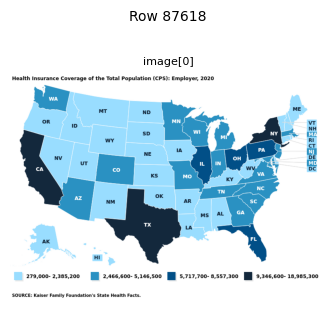

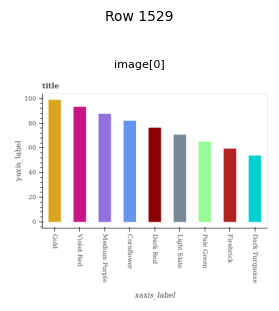

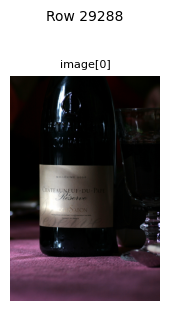

User,这是什么类型的葡萄酒？你的回答应非常简短。,
Assistant,Sabon。,
User,这瓶葡萄酒是哪一年的？请保持简短扼要。,
Assistant,2006年。,


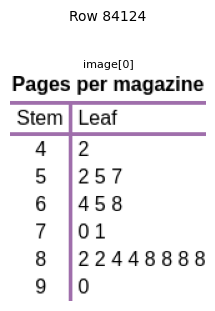

User,新闻专业学生莉兹统计了几本主要杂志的页数。有多少本杂志恰好有88页？,
Assistant,对于数字88，茎是8，叶是8。找到茎为8的那一行。在该行中，数出所有等于8的叶。你数出了4片叶子，它们在茎叶图中是蓝色的。有4本杂志恰好有88页。,


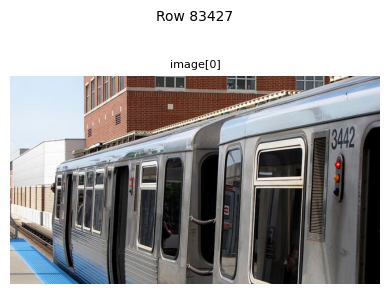

User,你能解释一下这张图片显示的是什么吗？,
Assistant,"这张图片显示了一辆停在车站的火车。聚焦于这列火车，它有几个值得注意的特征。火车似乎是金属制成的，很可能是不锈钢，因为其外观闪亮且反光。它由多节车厢串联连接而成。每节车厢都有一系列适度着色的窗户。这些窗户大多是方形的，形成统一的外观。在火车上存在的各种元素中，可以识别出以下几点：1. **火车车身**：外表面是金属的，看起来相当光滑，表明火车要么相对较新，要么保养良好。有一些轻微风化或磨损的迹象，但并不严重。2. **窗户**：窗户均匀分布，呈矩形。它们的着色调节了柔和的阳光反射，这可能表明是晴天或多云天气。这些窗户可能为乘客提供了外部视野，同时可能具有紫外线防护功能。3. **车门**：火车的车门设计便于乘客上下车。它们似乎是自动的，从其对齐方式和结构可以看出。在这张图片中，车门看起来是关闭的。4. **列车编号**：在最近一节车厢的右上角，可以看到数字""3442""，标识了正在运行的特定单元。5. **车站站台**：与火车相邻的车站站台高度与火车对齐，便于乘客进出。它与火车平行延伸，覆盖着蓝色材料，可能是为了提高能见度和安全标准。6. **背景中的建筑物**：火车后面可以看到一栋多层砖砌建筑。该建筑以其红棕色砖块和众多窗户为特征，是典型的城市建筑。旁边还有一个立面较浅的结构，表明存在多个设施，或者可能是另一个车站建筑。7. **标识和指示器**：火车附近可以观察到某些元素，如信号灯。这些通常用于管理火车运行，确保安全并遵守列车时刻表。**分析和关联信息：**鉴于设计和环境，图片中描绘的火车很可能是城市轨道交通系统的一部分。城市列车通常服务于高密度区域，提供必要的连接。金属和流线型设计功能性强，旨在减少维护需求并提高耐用性。车站的视觉结构表明它是服务于每日大量乘客的系统化网络的一部分。这种类型的交通系统对于减少城市交通拥堵和促进公共交通使用至关重要。**问题分析：**例如，如果问题是""火车的结构如何有助于乘客便利？""，采用思维链（CoT）方法将涉及：1. **识别**：确认火车的钢制车身、着色窗户和自动门。2. **功能性**：理解这些功能如何提升便利性。3. **结论**：金属车身确保了耐用性和易于维护，窗户提供了舒适的户外视野和潜在的紫外线防护，而自动门则简化了上下车流程，从而显著提升了乘客便利性。这种连贯而详细的描述将图像中的元素与相关的城市交通知识相结合，确保纯文本模型拥有全面的数据来回答相关问题。",


In [19]:
# Number of random rows to inspect per run — increase for deeper spot-checks
N_SAMPLES = 5

# Draw random indices without replacement
sample_indices = random.sample(range(len(train_ds)), k=N_SAMPLES)
print(f'Sampled row indices: {sample_indices}\n')

for i, idx in enumerate(sample_indices):
    display(HTML(f'<hr><h4>Sample {i+1}/{N_SAMPLES} — train row {idx}</h4>'))
    # get_row() fixes Linux image paths before PIL opens them on Windows.
    render_sample(get_row(train_ds_raw, idx), idx=idx, max_turns=4)

### 4-B  Random samples from the test split

The test split contains 64 reserved rows. Inspect a few to ensure the split looks balanced.

In [ ]:
N_TEST_SAMPLES = 3

test_indices = random.sample(range(len(test_ds)), k=N_TEST_SAMPLES)
print(f'Sampled test row indices: {test_indices}\n')

for i, idx in enumerate(test_indices):
    display(HTML(f'<hr><h4>Test sample {i+1}/{N_TEST_SAMPLES} — test row {idx}</h4>'))
    render_sample(get_row(test_ds_raw, idx), idx=idx, max_turns=4)

### 4-C  Inspect a specific row by index

Useful for drilling into a suspicious row found during the random pass above.

In [ ]:
# ── Change this index to inspect any specific training row ────────────────────
ROW_INDEX = 0

display(HTML(f'<h4>Inspecting train row {ROW_INDEX}</h4>'))
render_sample(get_row(train_ds_raw, ROW_INDEX), idx=ROW_INDEX)

## 5. Long-Response Spot-Check

Rows with very long assistant responses are good candidates for quality issues
(truncated translations, encoding artefacts, etc.). The cells below surface the
top-10 longest responses and let you inspect them individually.

In [ ]:
# Build a dataframe of (row_index, turn_index, assistant_length) for easy sorting
records = []
# Iterate train_ds_raw — text stats only, no image decoding needed here.
for row_idx, row in enumerate(train_ds_raw):
    for turn_idx, turn in enumerate(unpack_turns(row['texts'])):
        u = turn.get('user')        or ''
        a = turn.get('assistant')   or ''
        s = turn.get('source')      or ''
        records.append({
            'row_idx':      row_idx,
            'turn_idx':     turn_idx,
            'user_len':     len(u),
            'asst_len':     len(a),
            'source':       s,
            'asst_preview': a[:120].replace('\n', ' '),
        })

df = pd.DataFrame(records)

# Top-10 longest assistant responses
top10 = df.nlargest(10, 'asst_len')[['row_idx', 'turn_idx', 'asst_len', 'source', 'asst_preview']]
display(top10.reset_index(drop=True).style.set_caption('Top-10 Longest Assistant Responses'))

In [ ]:
# ── Render the single longest assistant response in full ──────────────────────
longest_row_idx = int(df['asst_len'].idxmax())
target_row_idx  = df.loc[longest_row_idx, 'row_idx']

display(HTML(f'<h4>Longest response — train row {target_row_idx}</h4>'))
render_sample(get_row(train_ds_raw, target_row_idx), idx=target_row_idx)

## 6. Image Quality Spot-Check

Render a grid of random images to visually verify that all images decode without artefacts.

In [ ]:
# Collect indices of rows that have at least one image
image_row_indices = [i for i, n in enumerate(num_images_per_row) if n > 0]
print(f'{len(image_row_indices):,} rows contain at least one image')

# Pick 16 random image rows and display their first image in a 4×4 grid
N_GRID = 16
grid_indices = random.sample(image_row_indices, k=min(N_GRID, len(image_row_indices)))

cols = 4
rows = (N_GRID + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
fig.suptitle('Random image sample (first image per row)', fontsize=12)

for ax in axes.flat:
    ax.axis('off')

for pos, row_idx in enumerate(grid_indices):
    # get_row() fetches and decodes the image, fixing any Linux paths for Windows.
    row = get_row(train_ds_raw, row_idx)
    img = row['images'][0]  # first image of the row
    ax  = axes[pos // cols][pos % cols]
    ax.imshow(img)
    ax.set_title(f'row {row_idx}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Source Label Distribution

Each turn carries a `source` tag that tracks which Cauldron sub-dataset the row came from.
This breakdown helps verify that the merge preserved the original subset proportions.

In [ ]:
# Count unique source tags across all turns in the training split
source_counter = Counter(df['source'])

source_df = (
    pd.DataFrame(source_counter.most_common(), columns=['source', 'turns'])
    .assign(pct=lambda x: (x['turns'] / x['turns'].sum() * 100).round(2))
)

display(source_df.style.set_caption('Source distribution (by turn count)'))

# Bar chart — top-20 sources by turn count
top_sources = source_df.head(20)
fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(top_sources['source'][::-1], top_sources['turns'][::-1], color='cornflowerblue')
ax.set_xlabel('Number of turns')
ax.set_title('Top-20 sources by turn count')
plt.tight_layout()
plt.show()